In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [3]:
train_path = "../data/raw/train_FD001.txt"

train_df = pd.read_csv(
    train_path,
    sep=r"\s+",
    header=None
)

In [4]:
columns = [
    "unit",
    "cycle",
    "setting_1",
    "setting_2",
    "setting_3",
    "sensor_1",
    "sensor_2",
    "sensor_3",
    "sensor_4",
    "sensor_5",
    "sensor_6",
    "sensor_7",
    "sensor_8",
    "sensor_9",
    "sensor_10",
    "sensor_11",
    "sensor_12",
    "sensor_13",
    "sensor_14",
    "sensor_15",
    "sensor_16",
    "sensor_17",
    "sensor_18",
    "sensor_19",
    "sensor_20",
    "sensor_21"
]

train_df.columns = columns

In [5]:
train_df.head()

,unit,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [7]:
train_df.shape

(20631, 26)

In [11]:
train_df["unit"].nunique()
lifetimes = train_df.groupby("unit")["cycle"].max()

lifetimes.head(10)
lifetimes.describe()

count    100.000000
mean     206.310000
std       46.342749
min      128.000000
25%      177.000000
50%      199.000000
75%      229.250000
max      362.000000
Name: cycle, dtype: float64

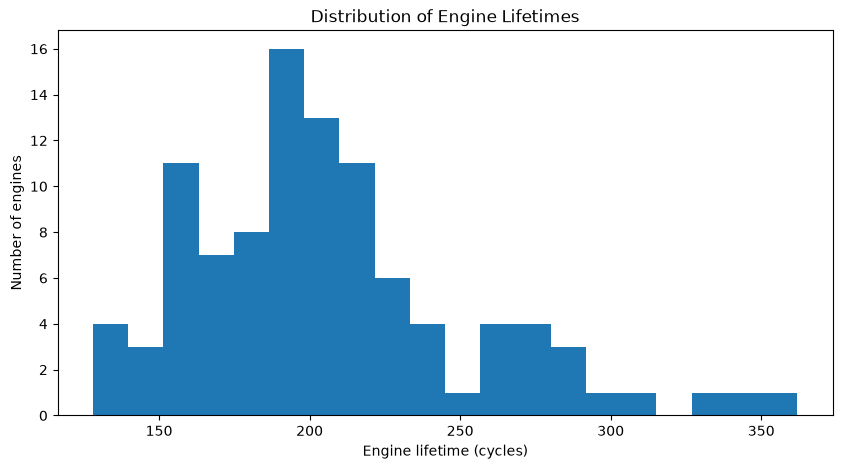

In [12]:
plt.figure(figsize=(10, 5))

plt.hist(lifetimes, bins=20)

plt.xlabel("Engine lifetime (cycles)")
plt.ylabel("Number of engines")
plt.title("Distribution of Engine Lifetimes")

plt.show()

In [14]:
train_df["RUL"] = (
    train_df.groupby("unit")["cycle"].transform("max")
    - train_df["cycle"]
)
train_df[["unit", "cycle", "RUL"]].head(10)

,unit,cycle,RUL
0,1,1,191
1,1,2,190
2,1,3,189
3,1,4,188
4,1,5,187
5,1,6,186
6,1,7,185
7,1,8,184
8,1,9,183
9,1,10,182


In [15]:
train_df.groupby("unit").tail(1)[["unit", "cycle", "RUL"]].head(10)


,unit,cycle,RUL
191,1,192,0
478,2,287,0
657,3,179,0
846,4,189,0
1115,5,269,0
1303,6,188,0
1562,7,259,0
1712,8,150,0
1913,9,201,0
2135,10,222,0


In [17]:
sensor_columns = [f"sensor_{i}" for i in range(1, 22)]

train_df[sensor_columns].describe().T


,count,mean,std,min,25%,50%,75%,max
sensor_1,20631.0,518.670000,0.000000e+00,518.6700,518.6700,518.6700,518.6700,518.6700
sensor_2,20631.0,642.680934,5.000533e-01,641.2100,642.3250,642.6400,643.0000,644.5300
sensor_3,20631.0,1590.523119,6.131150e+00,1571.0400,1586.2600,1590.1000,1594.3800,1616.9100
sensor_4,20631.0,1408.933782,9.000605e+00,1382.2500,1402.3600,1408.0400,1414.5550,1441.4900
sensor_5,20631.0,14.620000,5.329200e-15,14.6200,14.6200,14.6200,14.6200,14.6200
sensor_6,20631.0,21.609803,1.388985e-03,21.6000,21.6100,21.6100,21.6100,21.6100
sensor_7,20631.0,553.367711,8.850923e-01,549.8500,552.8100,553.4400,554.0100,556.0600
sensor_8,20631.0,2388.096652,7.098548e-02,2387.9000,2388.0500,2388.0900,2388.1400,2388.5600
sensor_9,20631.0,9065.242941,2.208288e+01,9021.7300,9053.1000,9060.6600,9069.4200,9244.5900
sensor_10,20631.0,1.300000,0.000000e+00,1.3000,1.3000,1.3000,1.3000,1.3000


In [18]:
sensor_std = train_df[sensor_columns].std()

sensor_std.sort_values()

sensor_1     0.000000e+00
sensor_10    0.000000e+00
sensor_19    0.000000e+00
sensor_18    0.000000e+00
sensor_16    3.469531e-18
sensor_5     5.329200e-15
sensor_6     1.388985e-03
sensor_15    3.750504e-02
sensor_8     7.098548e-02
sensor_13    7.191892e-02
sensor_21    1.082509e-01
sensor_20    1.807464e-01
sensor_11    2.670874e-01
sensor_2     5.000533e-01
sensor_12    7.375534e-01
sensor_7     8.850923e-01
sensor_17    1.548763e+00
sensor_3     6.131150e+00
sensor_4     9.000605e+00
sensor_14    1.907618e+01
sensor_9     2.208288e+01
dtype: float64

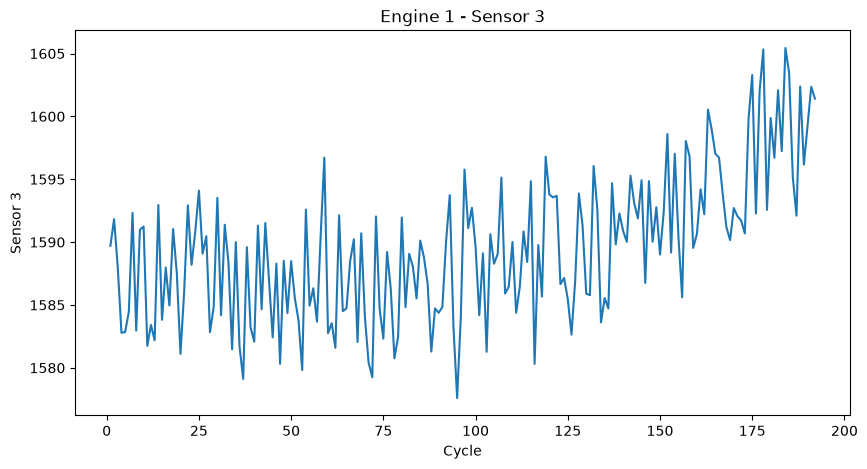

In [22]:
engine_1 = train_df[train_df["unit"] == 1]
plt.figure(figsize=(10, 5))

plt.plot(engine_1["cycle"], engine_1["sensor_3"])

plt.xlabel("Cycle")
plt.ylabel("Sensor 3")
plt.title("Engine 1 - Sensor 3")

plt.show()

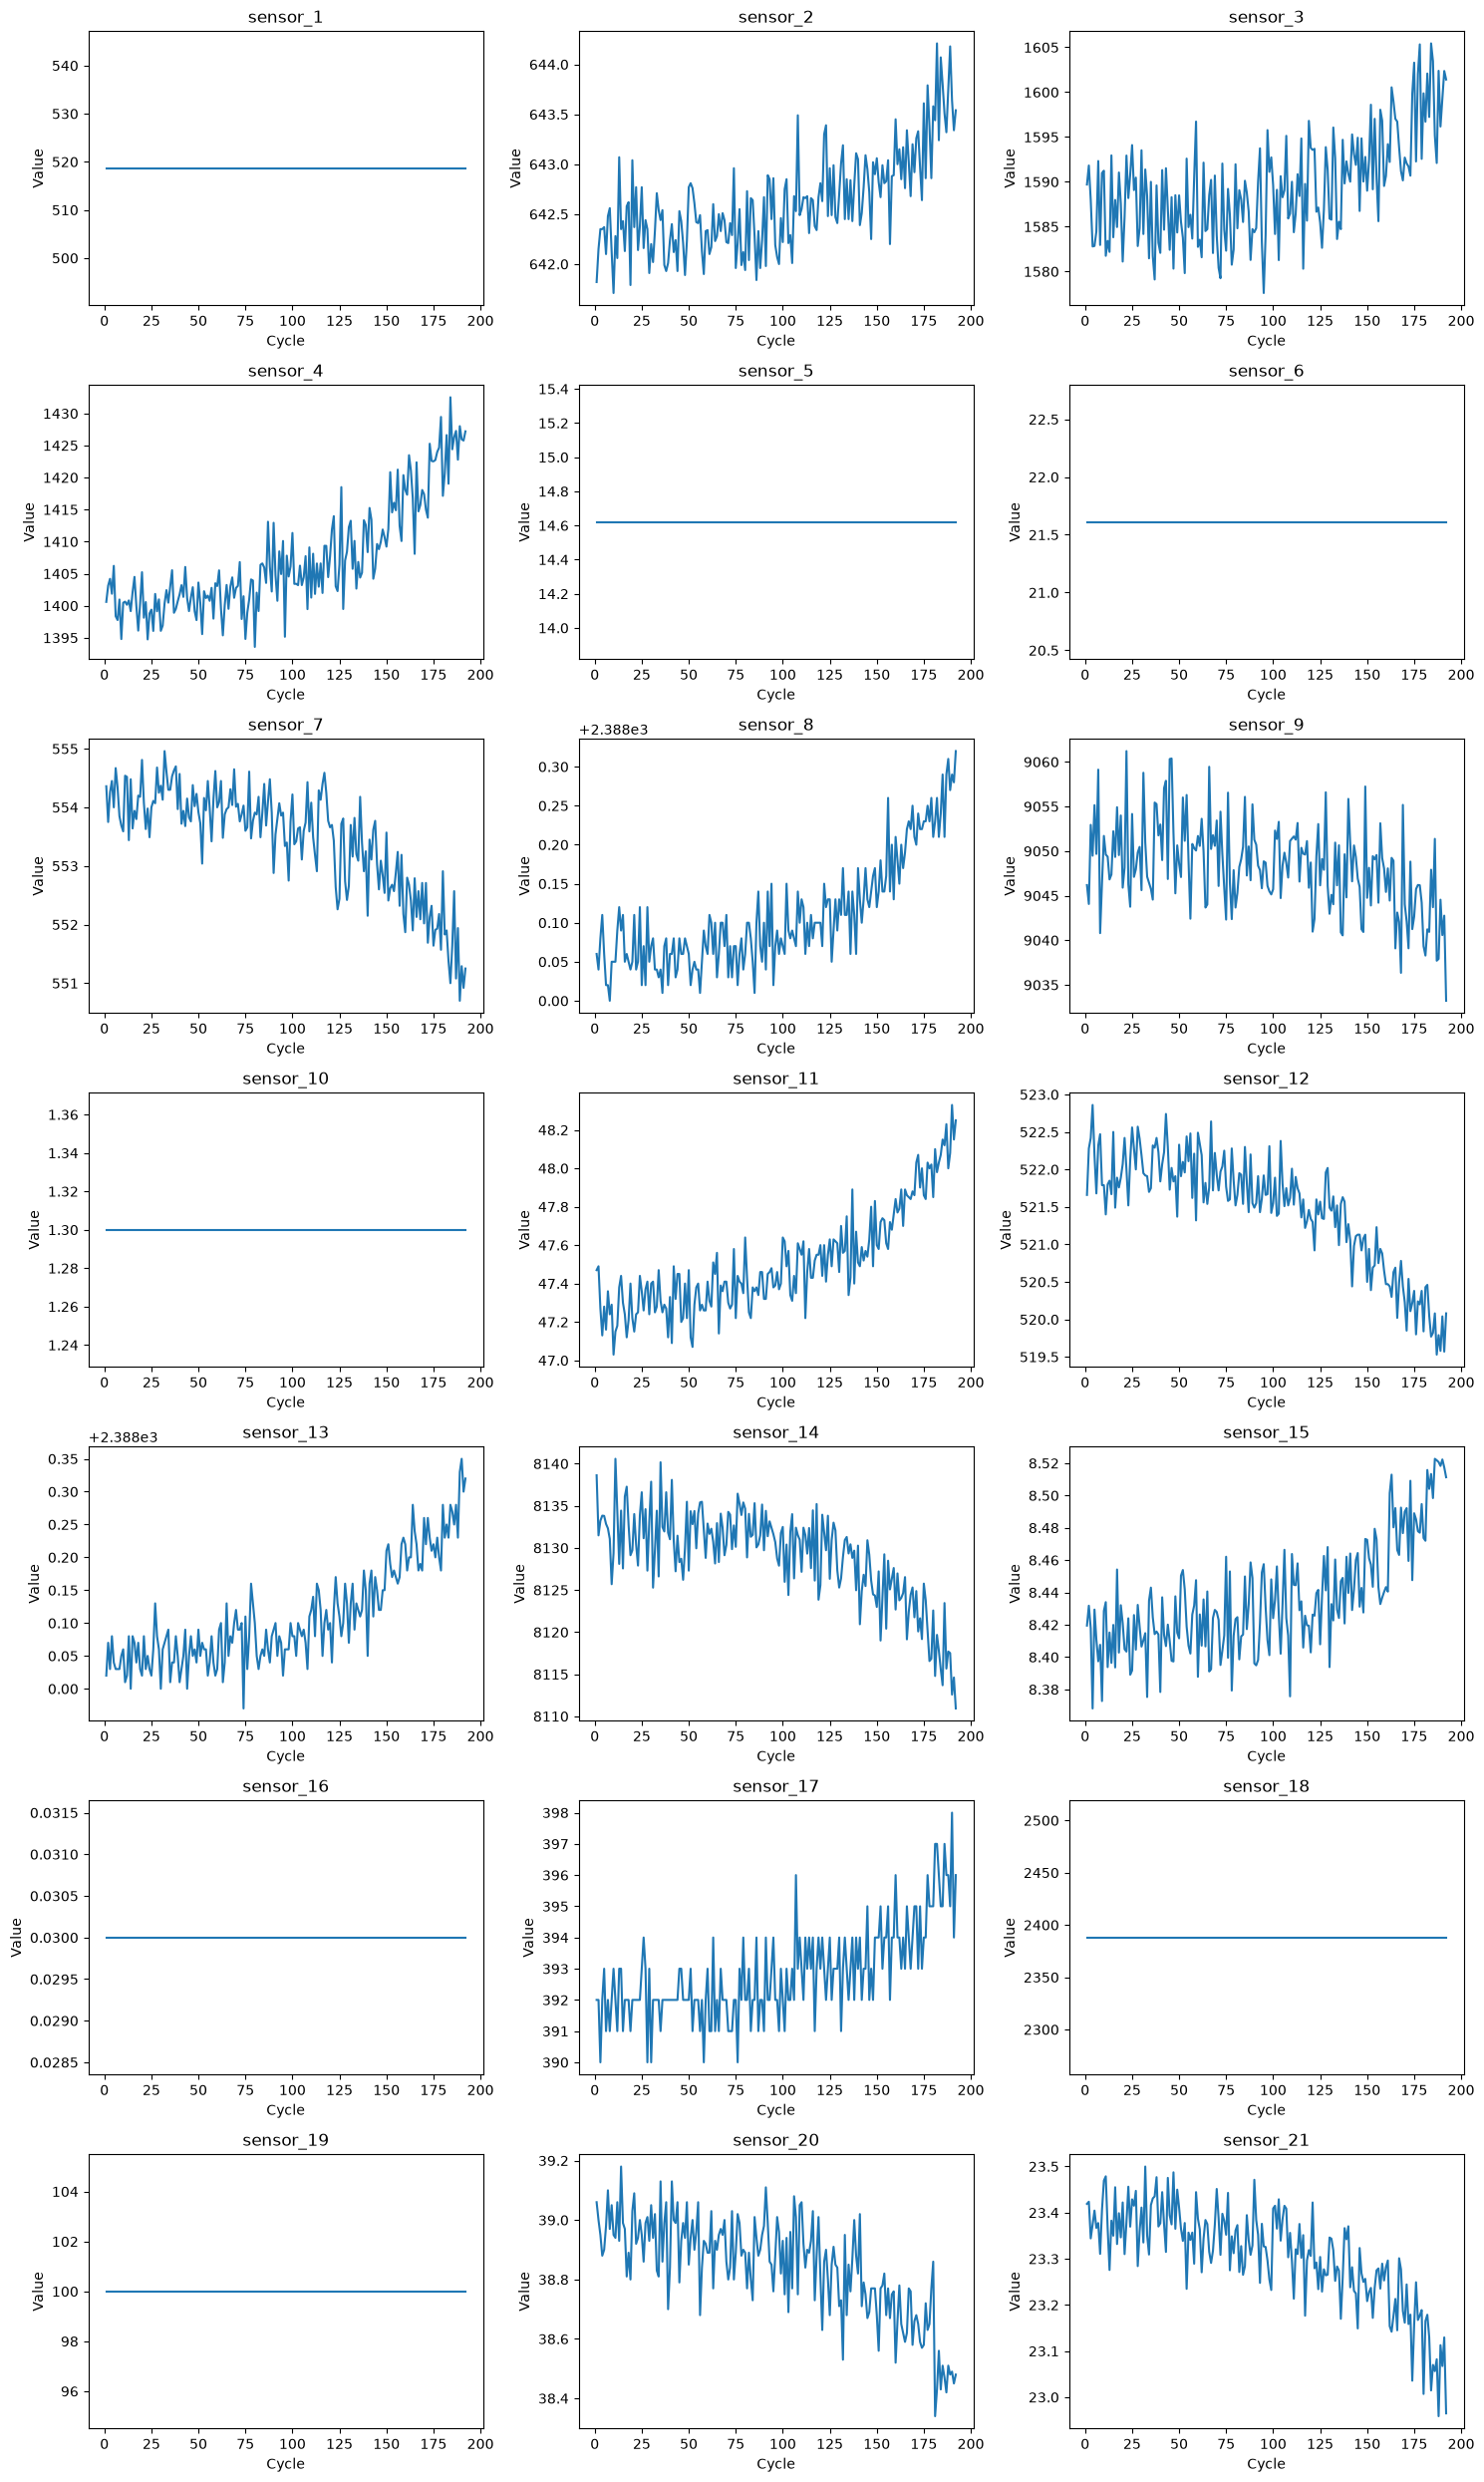

In [23]:
fig, axes = plt.subplots(7, 3, figsize=(15, 25))

for i, sensor in enumerate(sensor_columns):
    ax = axes[i // 3, i % 3]
    
    ax.plot(engine_1["cycle"], engine_1[sensor])
    ax.set_title(sensor)
    ax.set_xlabel("Cycle")
    ax.set_ylabel("Value")

plt.tight_layout()
plt.show()

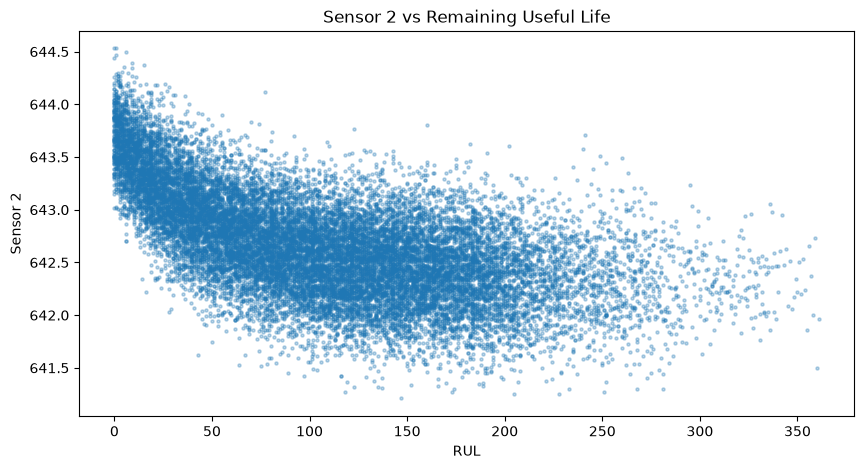

In [24]:
plt.figure(figsize=(10, 5))

plt.scatter(
    train_df["RUL"],
    train_df["sensor_2"],
    s=5,
    alpha=0.3
)

plt.xlabel("RUL")
plt.ylabel("Sensor 2")
plt.title("Sensor 2 vs Remaining Useful Life")

plt.show()

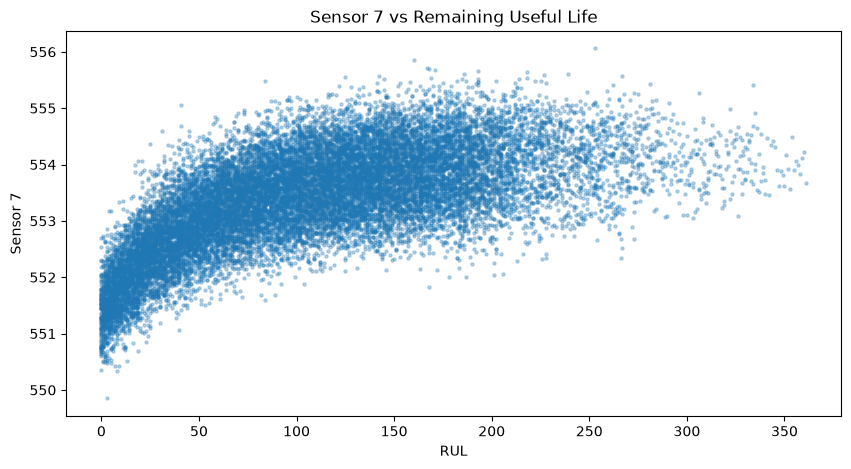

In [26]:
plt.figure(figsize=(10, 5))

plt.scatter(
    train_df["RUL"],
    train_df["sensor_7"],
    s=5,
    alpha=0.3
)

plt.xlabel("RUL")
plt.ylabel("Sensor 7")
plt.title("Sensor 7 vs Remaining Useful Life")

plt.show()